# Proyek Klasifikasi Gambar: Flowers Dataset (5 Kelas)
- **Nama:** Aqilla Zeba Fakhira
- **Email:** aqillazeba@gmail.com
- **ID Dicoding:** aqillaz

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

In [2]:
import urllib.request

url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
dataset_path = '/content/flower_photos.tgz'

print('Mendownload dataset...')
urllib.request.urlretrieve(url, dataset_path)
print('Download selesai!')

import tarfile
with tarfile.open(dataset_path, 'r:gz') as tar:
    tar.extractall('/content/')
print('Ekstraksi selesai!')

Mendownload dataset...
Download selesai!


/tmp/ipykernel_6203/1391868563.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content/')


Ekstraksi selesai!


In [3]:
base_dir = '/content/flower_photos'
classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print('Kelas yang tersedia:', classes)
print('Jumlah kelas:', len(classes))
print()

total = 0
for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    n = len(os.listdir(cls_path))
    total += n
    print(f'  {cls}: {n} gambar')
print(f'\nTotal gambar: {total}')

Kelas yang tersedia: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Jumlah kelas: 5

  daisy: 633 gambar
  dandelion: 898 gambar
  roses: 641 gambar
  sunflowers: 699 gambar
  tulips: 799 gambar

Total gambar: 3670


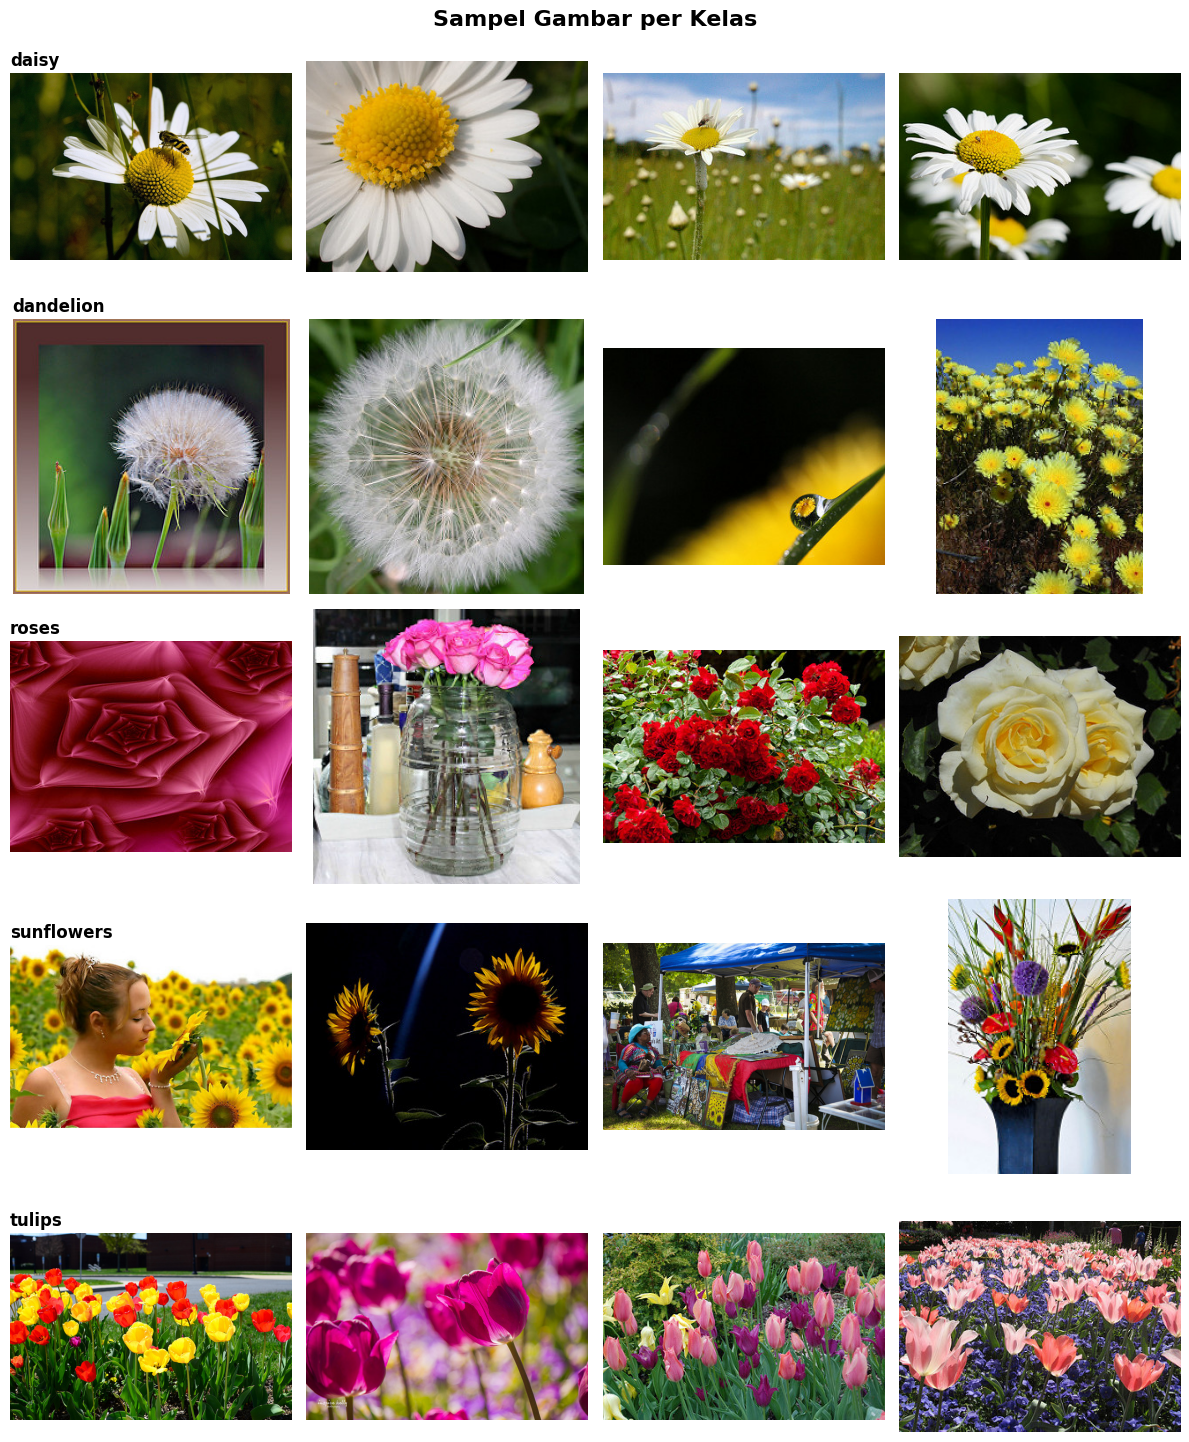

In [4]:
fig, axes = plt.subplots(len(classes), 4, figsize=(12, len(classes)*3))
fig.suptitle('Sampel Gambar per Kelas', fontsize=16, fontweight='bold')

for i, cls in enumerate(classes):
    cls_path = os.path.join(base_dir, cls)
    img_files = random.sample(os.listdir(cls_path), 4)
    for j, fname in enumerate(img_files):
        img = mpimg.imread(os.path.join(cls_path, fname))
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(cls, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

In [5]:
def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in sorted(os.listdir(directory)):
        subdir_path = os.path.join(directory, subdir)
        if not os.path.isdir(subdir_path):
            continue
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f'{subdir}: {num_images} gambar')
        total_images += num_images

        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            try:
                with Image.open(img_path) as img:
                    unique_sizes.add(img.size)
            except:
                pass

    print(f'\nTotal: {total_images}')
    print(f'Jumlah resolusi unik: {len(unique_sizes)}')
    print('Resolusi tidak seragam (sesuai saran rubrik: tanpa preprocessing):', len(unique_sizes) > 1)

print_images_resolution(base_dir)

daisy: 633 gambar
dandelion: 898 gambar
roses: 641 gambar
sunflowers: 699 gambar
tulips: 799 gambar

Total: 3670
Jumlah resolusi unik: 345
Resolusi tidak seragam (sesuai saran rubrik: tanpa preprocessing): True


### Data Preprocessing

#### Split Dataset

In [6]:
split_dir = '/content/flowers_split'
train_dir = os.path.join(split_dir, 'train')
val_dir   = os.path.join(split_dir, 'validation')
test_dir  = os.path.join(split_dir, 'test')

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

random.seed(42)

for cls in classes:
    cls_src = os.path.join(base_dir, cls)
    all_files = [f for f in os.listdir(cls_src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(all_files)

    n_total = len(all_files)
    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)

    splits = {
        train_dir: all_files[:n_train],
        val_dir:   all_files[n_train:n_train + n_val],
        test_dir:  all_files[n_train + n_val:]
    }

    for dest_dir, files in splits.items():
        dest_cls = os.path.join(dest_dir, cls)
        os.makedirs(dest_cls, exist_ok=True)
        for f in files:
            shutil.copy(os.path.join(cls_src, f), os.path.join(dest_cls, f))

print('=== Distribusi Dataset ===')
for split_name, split_path in [('Train', train_dir), ('Validation', val_dir), ('Test', test_dir)]:
    total_split = 0
    print(f'\n[{split_name}]')
    for cls in classes:
        n = len(os.listdir(os.path.join(split_path, cls)))
        total_split += n
        print(f'  {cls}: {n}')
    print(f'  --> Total: {total_split}')

=== Distribusi Dataset ===

[Train]
  daisy: 443
  dandelion: 628
  roses: 448
  sunflowers: 489
  tulips: 559
  --> Total: 2567

[Validation]
  daisy: 94
  dandelion: 134
  roses: 96
  sunflowers: 104
  tulips: 119
  --> Total: 547

[Test]
  daisy: 96
  dandelion: 136
  roses: 97
  sunflowers: 106
  tulips: 121
  --> Total: 556


In [7]:
IMG_SIZE   = (160, 160)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print('Label mapping:', train_generator.class_indices)

Found 2567 images belonging to 5 classes.
Found 547 images belonging to 5 classes.
Found 556 images belonging to 5 classes.
Label mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


## Modelling

In [8]:
NUM_CLASSES = len(classes)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(160, 160, 3), name='input_gambar')

x1 = Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1')(inputs)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(2, 2, name='maxpool_1')(x1)

x1 = Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2')(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(2, 2, name='maxpool_2')(x1)

x1 = Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2d_3')(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(2, 2, name='maxpool_3')(x1)
x1 = GlobalAveragePooling2D(name='gap_conv')(x1)

x2 = base_model(inputs, training=False)
x2 = GlobalAveragePooling2D(name='gap_mobilenet')(x2)

x = tf.keras.layers.Concatenate(name='merge')([x1, x2])

x = Dense(256, activation='relu', name='dense_1')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', name='dense_2')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)

model = tf.keras.Model(inputs, outputs, name='CNN_MobileNetV2_Flowers')
model.summary()

layer_types = [type(l).__name__ for l in model.layers]
print('\n✅ Conv2D    :', 'Conv2D' in layer_types)
print('✅ MaxPool2D :', 'MaxPooling2D' in layer_types)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "CNN_MobileNetV2_Flowers"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_gambar        │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 160, 160,  │        896 │ input_gambar[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 160, 160,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_1           │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 80,    │     18,496 │ maxpool_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_2           │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 40,    │     73,856 │ maxpool_2[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_3           │ (None, 20, 20,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 5, 5,      │  2,257,984 │ input_gambar[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_conv            │ (None, 128)       │          0 │ maxpool_3[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_mobilenet       │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 1408)      │          0 │ gap_conv[0][0],   │
│                     │                   │            │ gap_mobilenet[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    360,704 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,747,397 (10.48 MB)

 Trainable params: 488,453 (1.86 MB)

 Non-trainable params: 2,258,944 (8.62 MB)


✅ Conv2D    : True
✅ MaxPool2D : True


In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=== FASE 1: Feature Extraction ===')
history1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_phase1,
    verbose=1
)

val_acc_phase1 = max(history1.history['val_accuracy'])
print(f'\nFase 1 selesai. Best val_accuracy: {val_acc_phase1*100:.2f}%')

print('\n=== FASE 2: Fine-Tuning ===')

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = len([l for l in base_model.layers if l.trainable])
print(f'Layer yang di-unfreeze: {trainable_count}')

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history2 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

print('\nTraining selesai!')

history_combined = {}
for key in history1.history:
    history_combined[key] = history1.history[key] + history2.history[key]

class CombinedHistory:
    def __init__(self, combined):
        self.history = combined

history = CombinedHistory(history_combined)

=== FASE 1: Feature Extraction ===
Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.5263 - loss: 1.4546
Epoch 1: val_accuracy improved from None to 0.80439, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6541 - loss: 1.0025 - val_accuracy: 0.8044 - val_loss: 0.5536 - learning_rate: 0.0010
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.7931 - loss: 0.5839
Epoch 2: val_accuracy improved from 0.80439 to 0.85923, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 43s 538ms/step - accuracy: 0.7970 - loss: 0.5869 - val_accuracy: 0.8592 - val_loss: 0.3899 - learning_rate: 0.0010
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8152 - loss: 0.5326
Epoch 3: val_accuracy did not improve from 0.85923
81/81 ━━━━━━━━━━━━━━━━━━━━ 26s 318ms/step - accuracy: 0.8044 - loss

## Evaluasi dan Visualisasi

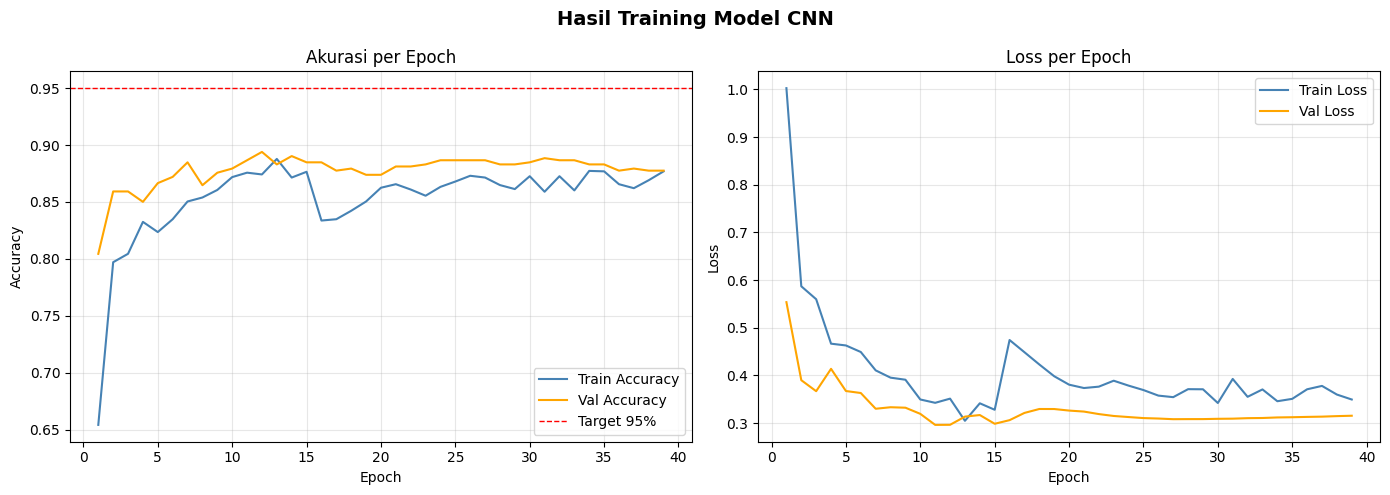

In [10]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hasil Training Model CNN', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, acc, label='Train Accuracy', color='steelblue')
axes[0].plot(epochs_range, val_acc, label='Val Accuracy', color='orange')
axes[0].axhline(y=0.95, color='red', linestyle='--', linewidth=1, label='Target 95%')
axes[0].set_title('Akurasi per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, loss, label='Train Loss', color='steelblue')
axes[1].plot(epochs_range, val_loss, label='Val Loss', color='orange')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
print('=== Evaluasi Model ===')
train_loss, train_acc = model.evaluate(train_generator, verbose=0)
print(f'Train Accuracy : {train_acc*100:.2f}%')
print(f'Train Loss     : {train_loss:.4f}')

test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f'\nTest Accuracy  : {test_acc*100:.2f}%')
print(f'Test Loss      : {test_loss:.4f}')

print()
if train_acc >= 0.85 and test_acc >= 0.85:
    print('✅ Kriteria akurasi TERPENUHI (Train & Test >= 85%)')
else:
    print('❌ Akurasi belum memenuhi kriteria 85%')

if train_acc >= 0.95 and test_acc >= 0.95:
    print('Akurasi Terpenuhi (Train & Test >= 95%)')

=== Evaluasi Model ===
Train Accuracy : 92.64%
Train Loss     : 0.1931

Test Accuracy  : 87.23%
Test Loss      : 0.3816

✅ Kriteria akurasi TERPENUHI (Train & Test >= 85%)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


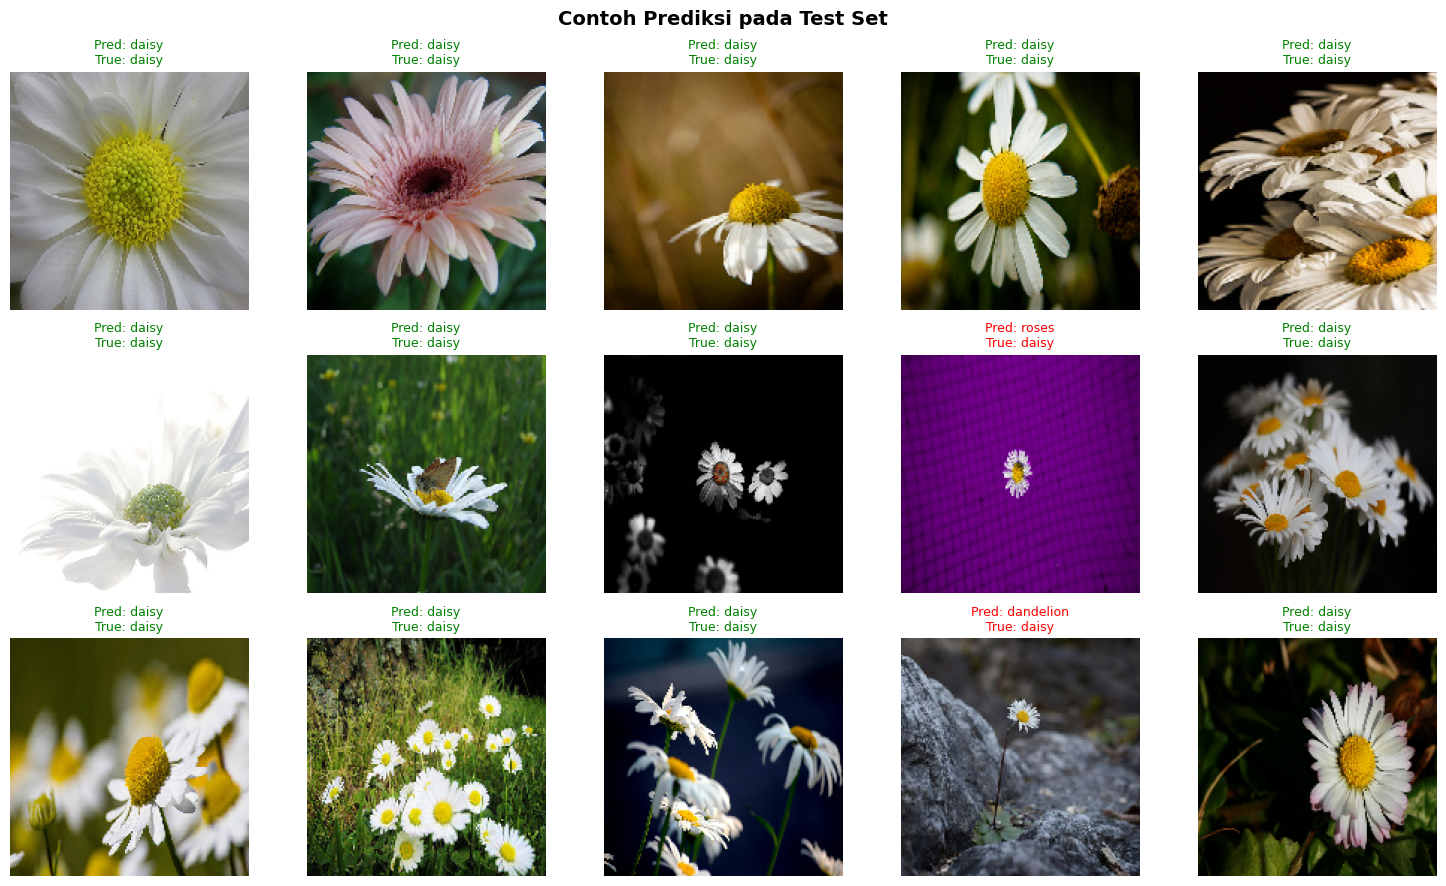

In [12]:
class_names = list(train_generator.class_indices.keys())

test_generator.reset()
images, labels = next(test_generator)
preds = model.predict(images)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Contoh Prediksi pada Test Set', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i >= len(images):
        ax.axis('off')
        continue
    ax.imshow(images[i])
    pred_class = class_names[np.argmax(preds[i])]
    true_class = class_names[np.argmax(labels[i])]
    color = 'green' if pred_class == true_class else 'red'
    ax.set_title(f'Pred: {pred_class}\nTrue: {true_class}', color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Konversi Model

In [13]:
os.makedirs('/content/submission', exist_ok=True)

keras_path = '/content/submission/model.keras'
model.save(keras_path)
print('✅ Native Keras model disimpan di:', keras_path)

saved_model_path = '/content/submission/saved_model'
model.export(saved_model_path)
print('✅ SavedModel berhasil disimpan di:', saved_model_path)

loaded = tf.saved_model.load(saved_model_path)
print('✅ SavedModel berhasil diload kembali')
print('File SavedModel:')
for f in os.listdir(saved_model_path):
    print(f'  - {f}')


✅ Native Keras model disimpan di: /content/submission/model.keras
Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_gambar')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132628753370960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623607397072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623607396112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623607397840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623607398224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623607397648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623607397264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623607397456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623607396880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132

In [14]:
tflite_dir = '/content/submission/tflite'
os.makedirs(tflite_dir, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantization ringan
tflite_model = converter.convert()

tflite_path = os.path.join(tflite_dir, 'model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

label_path = os.path.join(tflite_dir, 'label.txt')
with open(label_path, 'w') as f:
    for cls in class_names:
        f.write(cls + '\n')

print('✅ TF-Lite model disimpan di:', tflite_path)
print('✅ Label disimpan di:', label_path)
print(f'   Ukuran TF-Lite: {os.path.getsize(tflite_path)/1024:.1f} KB')


✅ TF-Lite model disimpan di: /content/submission/tflite/model.tflite
✅ Label disimpan di: /content/submission/tflite/label.txt
   Ukuran TF-Lite: 2946.4 KB


In [15]:
!pip install tensorflowjs -q

tfjs_dir = '/content/submission/tfjs_model'
os.makedirs(tfjs_dir, exist_ok=True)

!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    /content/submission/saved_model \
    /content/submission/tfjs_model

print('\n✅ TFJS model disimpan di:', tfjs_dir)
print('File yang dihasilkan:')
for f in sorted(os.listdir(tfjs_dir)):
    size = os.path.getsize(os.path.join(tfjs_dir, f))
    print(f'  - {f} ({size/1024:.1f} KB)')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompa

## Inference (Optional)

Input shape : [  1 160 160   3]
Output shape: [1 5]

=== Hasil Inference TF-Lite ===


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Gambar 1: Prediksi=daisy (99.9%), Aktual=daisy
Gambar 2: Prediksi=daisy (99.7%), Aktual=daisy
Gambar 3: Prediksi=daisy (100.0%), Aktual=daisy
Gambar 4: Prediksi=daisy (100.0%), Aktual=daisy
Gambar 5: Prediksi=daisy (100.0%), Aktual=daisy


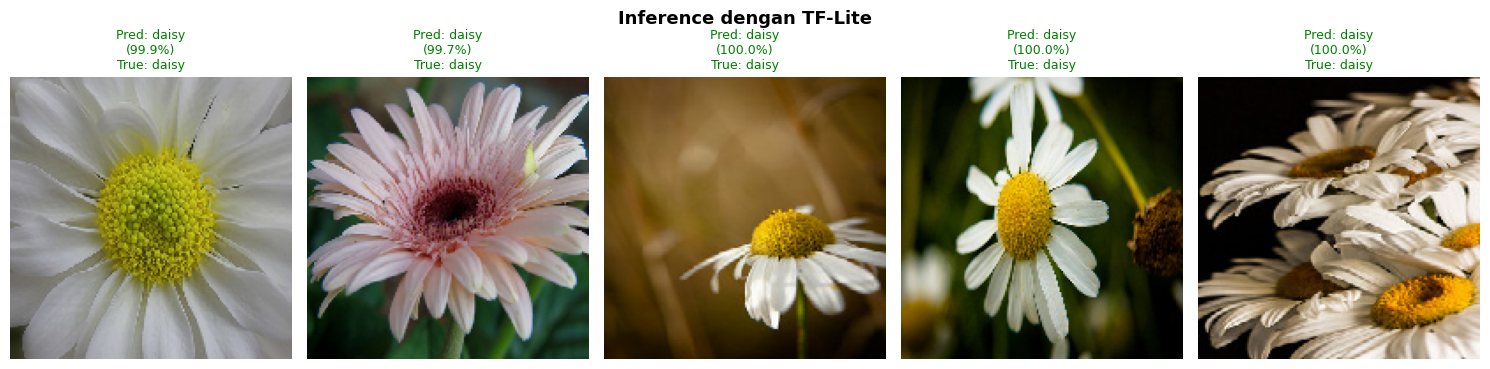


✅ Inference selesai!


In [16]:
import numpy as np

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input shape :', input_details[0]['shape'])
print('Output shape:', output_details[0]['shape'])

test_generator.reset()
sample_images, sample_labels = next(test_generator)
sample_images = sample_images[:5]
sample_labels = sample_labels[:5]

print('\n=== Hasil Inference TF-Lite ===')
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Inference dengan TF-Lite', fontsize=13, fontweight='bold')

for i in range(5):
    img = sample_images[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])

    pred_idx  = np.argmax(output[0])
    pred_conf = output[0][pred_idx] * 100
    pred_cls  = class_names[pred_idx]
    true_cls  = class_names[np.argmax(sample_labels[i])]

    color = 'green' if pred_cls == true_cls else 'red'
    axes[i].imshow(sample_images[i])
    axes[i].set_title(f'Pred: {pred_cls}\n({pred_conf:.1f}%)\nTrue: {true_cls}', color=color, fontsize=9)
    axes[i].axis('off')
    print(f'Gambar {i+1}: Prediksi={pred_cls} ({pred_conf:.1f}%), Aktual={true_cls}')

plt.tight_layout()
plt.show()
print('\n✅ Inference selesai!')